# Whole Sale Customers with PyCaret
This notebook performs basic customer segmentation using PyCaret's low-code clustering tools on `Wholesale customers data.csv`.

Steps:
1. Load dataset (`Wholesale customers data.csv`).
2. Initialize `ClusteringExperiment` and `setup`.
3. Use `compare_models()` to choose a clustering model (or create `kmeans`).
4. Evaluate the model and assign cluster labels.
5. Save the model for future use.

In [1]:
# Imports
import pandas as pd
import numpy as np

In [2]:
# Load dataset
data = pd.read_csv('D:\Pycaret(1)\pycaret_assignment\clustering\Wholesale customers data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# PyCaret clustering setup
from pycaret.clustering import ClusteringExperiment
clustering = ClusteringExperiment()
clustering.setup(data=data, session_id=123, normalize=True, use_gpu=True)

,Description,Value
0,Session id,123
1,Original data shape,"(440, 8)"
2,Transformed data shape,"(440, 8)"
3,Numeric features,8
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,Normalize,True
9,Normalize method,zscore


In [4]:
kmeans = clustering.create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.3166,117.7945,0.9666,0,0,0


In [5]:
clustering.models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch
kmodes,K-Modes Clustering,kmodes.kmodes.KModes


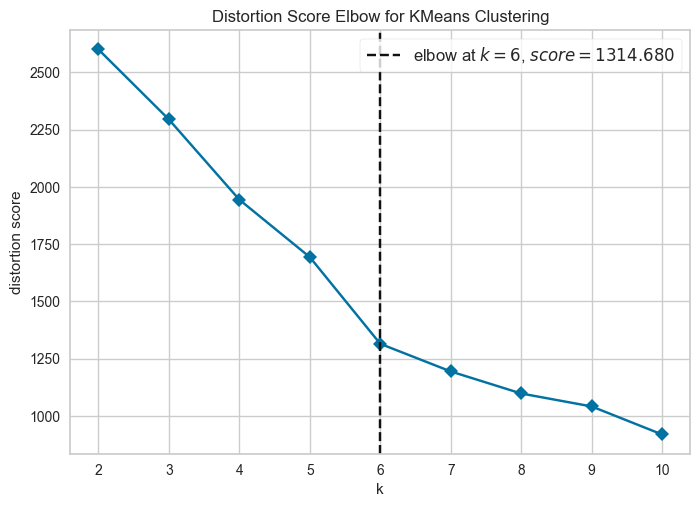

In [6]:
clustering.plot_model(kmeans, plot='cluster')
clustering.plot_model(kmeans,"elbow")

In [7]:
# Save the trained pipeline, assign cluster labels, and predict on data
clustering.save_model(kmeans, 'kmeans_segmentation_model')
# Assign cluster labels to the training data
assigned = clustering.assign_model(kmeans)
assigned.head()
# Predict cluster labels for new/unseen data (example uses same dataset)
predictions = clustering.predict_model(kmeans, data=data)
predictions.head()

Transformation Pipeline and Model Successfully Saved


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,1.448652,0.590668,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,Cluster 0
1,1.448652,0.590668,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,Cluster 0
2,1.448652,0.590668,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,Cluster 0
3,-0.690297,0.590668,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,Cluster 1
4,1.448652,0.590668,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,Cluster 0
